# Введение в машинное обучение, АБД

## НИУ ВШЭ, 2025-26 учебный год

# Домашнее задание 1. Часть 2. Регрессия и инференс модели

Задание выполнил(а):
Очирова Дельгира

В этом домашнем задании вам будет необходимо:
*  обучить модель регрессии для предсказания стоимости автомобилей;
*  реализовать веб-сервис для применения построенной модели на новых данных

> Оценка за домашнее задание = $min(\text{ваш балл}, 33)$

## Общая информация

__Внимание!__  

* Домашнее задание выполняется самостоятельно
* Не допускается помощь в решении домашнего задания от однокурсников или третьих лиц. «Похожие» решения считаются плагиатом, и все задействованные студенты — в том числе и те, у кого списали, — не могут получить за него больше 0 баллов
* Использование в решении домашнего задания за рамками справочной и образовательной информации генеративных моделей (ChatGPT и так далее) для генерации кода задания считается плагиатом, и такое домашнее задание оценивается в 0 баллов

**Примечание**

В каждой части оцениваются как код, **так и ответы на вопросы.** Вопросы подсвечены синим цветом.

Если нет одного и/или другого, то часть баллов или все баллы за соответствующее задание снимается.

## Импорт библиотек, установка констант

In [96]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random
import seaborn as sns

In [97]:
CARS_TRAIN = 'https://github.com/evgpat/datasets/raw/refs/heads/main/cars_train.csv'
CARS_TEST = 'https://github.com/evgpat/datasets/raw/refs/heads/main/cars_test.csv'

In [98]:
RANDOM_STATE = 42

In [99]:
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

## Задание 0

Для чего фиксируем сиды в ноутбуке?

для проведения эксперимента на одних выбранных случанйых данных

## Часть 1 | EDA




Первая часть состоит из классических шагов EDA:

- Базовый EDA и обработка признаков
- Визуализации признаков и их анализ

В следующих частях вы увидите бонусные задания. Бонусные задания выделены как **Дополнительное задание/Бонус**. Вы можете выполнять их, чтобы в случае ошибок в основных задачах всё равно набрать за работу максимум. Кроме того, дополнительные задания позволяют вам углубить знания.

Призываем активно использовать их!

## **Простейший EDA и обработка признаков (4.5 балла)**

In [100]:
df_train = pd.read_csv(CARS_TRAIN)
df_test = pd.read_csv(CARS_TEST)

print("Train data shape:", df_train.shape)
print("Test data shape: ", df_test.shape)

Train data shape: (6999, 13)
Test data shape:  (1000, 13)


### **Задание 1.(1.2 балла)**
Выполните операции, направленные на базовое исследование данных:

- [ ] Посмотрите, есть ли в датасете пропуски и дубликаты. Запишите/выведите названия колонок, для которых есть пропущенные значения (0.1 балла)
- [ ] Посмотрите, есть ли в данных явные дубликаты (0.05 балла)
- [ ] Постройте дашборд в одну строку, используя [ydata-profilling](https://github.com/ydataai/ydata-profiling) (0.15 балла)
- [ ] Опишите базовые выводы (какие — выберите сами), используя дашборд (0.2 балла)

In [101]:
!pip install ydata-profiling

In [102]:
#проверка пропусков
missing_cols = df_train.columns[df_train.isnull().any()].tolist()
print("Колонки с пропущенными значениями:", missing_cols)

#проверка дубликатов
duplicates = df_train.duplicated().sum()
if duplicates > 0:
    print(f"Количество дубликатов: {duplicates}")
else:
    print("Дубликатов нет")


#дашборд
from ydata_profiling import ProfileReport

ProfileReport(df_train, minimal=True).to_file("data.html")


print("Колонки с пропусками: mileage, engine, max_power, torque, seats | Дубликатов: 985")

Колонки с пропущенными значениями: ['mileage', 'engine', 'max_power', 'torque', 'seats']
Количество дубликатов: 985


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 13/13 [00:00<00:00, 17.07it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

Колонки с пропусками: mileage, engine, max_power, torque, seats | Дубликатов: 985


### **Задание 2 (0.6 балла)**
Проанализируйте статистики датасета.

**Ваша задача:**
- [ ] Посчитайте основные статистики по числовым столбцам для трейна и теста
- [ ] Посчитайте основные статистики по категориальным столбцам для трейна и теста
- [ ] Сравните среднее и медиану внутри `train`, внутри `test` и между собой. О чём могут говорить результаты?

**Подсказка:**

Используте ``.describe()`` с нужным(и) аргументом(-ами).

In [103]:
#числовые статистики
df_train.describe().T
df_test.describe().T

#категориальные статистики
df_train.describe(include=['object']).T
df_test.describe(include=['object']).T

#сравнение mean и median
num_cols = df_train.select_dtypes(include=['number']).columns

pd.DataFrame({
    'Train_Mean': df_train[num_cols].mean().round(2),
    'Train_Median': df_train[num_cols].median().round(2),
    'Test_Mean': df_test[num_cols].mean().round(2),
    'Test_Median': df_test[num_cols].median().round(2),
    'Mean_Diff': (df_train[num_cols].mean() - df_test[num_cols].mean()).round(2)
})



,Train_Mean,Train_Median,Test_Mean,Test_Median,Mean_Diff
year,2013.82,2015.0,2013.68,2014.0,0.14
selling_price,639515.20,450000.0,617901.04,434999.0,21614.16
km_driven,69584.62,60000.0,71393.34,61500.0,-1808.73
seats,5.42,5.0,5.41,5.0,0.01


#### Вывод:

1.selling_price и km_driven: среднее больше медианы, распределение скошено вправо, есть выбросы

year: среднее меньше медианы, распределение скошено влево

seats: среднее ~ медиана

Train vs Test: выборки однородны

### **Задание 3 (0.6 балла)**

- [ ] Посмотрите, есть ли в трейне объекты с одинаковым признаковым описанием (целевую переменную следует исключить). Если есть, то сколько? (0.05 балла)
- [ ] Отобразите такие объекты (0.05 балла)
- [ ] Удалите повторяющиеся строки. Если при одинаковом признаковом описании цены на автомобили отличаются, то оставьте первую строку по этому автомобилю (0.05 балла)
- [ ]  Обновите индексы строк таким образом, чтобы они шли от 0 без пропусков (0.05 балла)

In [104]:
#проверка
feature_cols = df_train.columns.drop('selling_price')
duplicates_mask = df_train.duplicated(subset=feature_cols, keep=False)
duplicates_count = duplicates_mask.sum()
print(f"Кол-во объектов с таким же названием: {duplicates_count}")

#отображение объектов с одинаковыми названиями
duplicate_rows = df_train[duplicates_mask].sort_values(by=feature_cols.tolist())
print("\nСписок объектов с одинкаовыми названиями:")
print(duplicate_rows.head(10))

Кол-во объектов с таким же названием: 1799

Список объектов с одинкаовыми названиями:
                                      name  year  selling_price  km_driven  \
1703  Audi Q3 2.0 TDI Quattro Premium Plus  2017        2825000      22000   
6307  Audi Q3 2.0 TDI Quattro Premium Plus  2017        2825000      22000   
1836               Audi Q5 3.0 TDI Quattro  2014        1850000      76131   
6704               Audi Q5 3.0 TDI Quattro  2014        1850000      76131   
117             Audi Q5 35TDI Premium Plus  2018        3975000      31800   
1337            Audi Q5 35TDI Premium Plus  2018        3975000      31800   
1595            Audi Q5 35TDI Premium Plus  2018        3975000      31800   
2787            Audi Q5 35TDI Premium Plus  2018        3975000      31800   
4485            Audi Q5 35TDI Premium Plus  2018        3975000      31800   
6640            Audi Q5 35TDI Premium Plus  2018        3975000      31800   

        fuel seller_type transmission        owner     

In [105]:
#удаление дубликатов
df_train_clean = df_train.drop_duplicates(subset=feature_cols, keep='first')

#изменение индексов
df_train_clean = df_train_clean.reset_index(drop=True)

#обновляем исходную переменную
df_train = df_train_clean

In [106]:
assert df_train.shape == (5840, 13)

### **Задание 4 (0.6 балла)**

Вы могли заметить, что с признаками ``mileage, engine, max_power и torque`` всё не очень хорошо. Они распознаются как строки (можно убедиться в этом, вызвав `data.dtypes`). Однако эти переменные не являются категориальными, они — числа. Соответственно, нужно привести их к числовому виду.

**Задача :**
* [ ] Уберите единицы измерения для признаков ``mileage, engine, max_power``.
* [ ] Приведите тип данных к ``float``.
* [ ] Предобработайте признак `torque` — разделите его на два: собственно `torque` и `max_torque_rpm`. Учтите единицы измерения


**Важно**
- Все действия нужно производить над обоими датасетами — `train` и `test`.

In [107]:
print(df_test.dtypes)

name              object
year               int64
selling_price      int64
km_driven          int64
fuel              object
seller_type       object
transmission      object
owner             object
mileage           object
engine            object
max_power         object
torque            object
seats            float64
dtype: object


In [108]:
def clean_numeric(x):
    if pd.isna(x):
        return np.nan
    x = str(x)
    if x == 'bhp':
        return np.nan
    try:
        return float(x.split()[0].replace(',', ''))
    except:
        return np.nan

def parse_torque(x):
    if pd.isna(x):
        return np.nan, np.nan
    s = str(x).replace('@', ' ').replace('at', ' ')
    parts = s.split()
    try:
        torque_val = float(parts[0])
    except:
        torque_val = np.nan
    try:
        rpm_val = float(parts[-1]) if len(parts) > 1 else np.nan
    except:
        rpm_val = np.nan
    return torque_val, rpm_val

for col in ['mileage', 'engine', 'max_power']:
    df_train[col] = df_train[col].apply(clean_numeric)
    df_test[col] = df_test[col].apply(clean_numeric)

for df in [df_train, df_test]:
    torque_vals, rpm_vals = zip(*df['torque'].apply(parse_torque))
    df['torque'] = torque_vals
    df['max_torque_rpm'] = rpm_vals
print(df_train[['mileage', 'engine', 'max_power', 'torque', 'max_torque_rpm']].dtypes)

mileage           float64
engine            float64
max_power         float64
torque            float64
max_torque_rpm    float64
dtype: object


### **Задание 5 (0.6 балла)**

На первом шаге мы обнаружили пропуски. Давайте избавимся от них.

**Задание:**
- [ ] Заполните пропуски в столбцах медианами. Убедитесь, что после заполнения пропусков не осталось.
- [ ] Почему стоит применять именно медиану. Могли ли мы применить среднее? Обоснуйте свое рассуждение.
- [ ] Как правильно считать медиану для заполнения? Выберите верное утверждение:
 - По тестовым свою, по тренировочным — свою
 - По тренировочным данным для `train` и `test`






In [109]:
print("Пропуски до:", df_train.isnull().sum().sum(), "/", df_test.isnull().sum().sum())

for col in df_train.columns:
    if df_train[col].isnull().any():
        med = df_train[col].median()
        df_train[col] = df_train[col].fillna(med)
        df_test[col] = df_test[col].fillna(med)

print("Пропуски после:", df_train.isnull().sum().sum(), "/", df_test.isnull().sum().sum())

Пропуски до: 11938 / 1998
Пропуски после: 0 / 0


Медиана робастна к выбросам. В данных о ценах и характеристиках автомобилей есть сильные выбросы (дорогие машины, большой пробег, объем двигателя).
Среднее подвержено влиянию выбросов и может исказить распределение. Медиана в подобных ситуациях
лучше показывает среднее значение.


Медиану необходимо вычислять только на train.

### **Задание 6 (0.6 балла)**

Теперь, когда не осталось пропусков, давайте преобразуем столбцы к более подходящим типам. А именно столбцы ``engnine`` и ``seats`` к приведем к `int`.

- [ ] Осуществите приведение столбцов к необходимому типу.
- [ ] Ответье на вопрос — почему (хоть мы этого и не делаем) ``seats``, возможно рассмотреть как категориальную переменную?

In [110]:
# Заполнение пропусков в engine и seats перед преобразованием
df_train['engine'] = df_train['engine'].fillna(df_train['engine'].median()).astype(int)
df_train['seats'] = df_train['seats'].fillna(df_train['seats'].median()).astype(int)

df_test['engine'] = df_test['engine'].fillna(df_train['engine'].median()).astype(int)
df_test['seats'] = df_test['seats'].fillna(df_train['seats'].median()).astype(int)

print(df_train[['engine', 'seats']].dtypes)
print(df_test[['engine', 'seats']].dtypes)

engine    int64
seats     int64
dtype: object
engine    int64
seats     int64
dtype: object


seat - это дискретный набор (2,4,5,6,7,8)

### **Задание 7 (0.3 балла)**

Снова вызовите метод describe и проанализируйте статистики.

**Ответье на вопрос:**
- [ ] Есть ли основания предполагать, что заполнение пропусков свдинуло наши распределения? Могло ли это вообще возникнуть?

In [111]:
df_train.describe()

,year,selling_price,km_driven,mileage,engine,max_power,torque,seats,max_torque_rpm
count,5840.000000,5.840000e+03,5.840000e+03,5840.000000,5840.000000,5840.000000,5840.000000,5840.000000,5840.000000
mean,2013.428425,5.229601e+05,7.395224e+04,19.430841,1429.448973,87.906371,23.166678,5.426712,1900.308219
std,4.095622,5.354320e+05,6.007114e+04,3.985973,485.662834,31.640418,23.469342,0.982344,13.596623
min,1983.000000,2.999900e+04,1.000000e+00,0.000000,624.000000,0.000000,5.700000,2.000000,1900.000000
25%,2011.000000,2.500000e+05,3.900000e+04,16.950000,1197.000000,68.000000,20.400000,5.000000,1900.000000
50%,2014.000000,4.050000e+05,7.000000e+04,19.370000,1248.000000,81.860000,20.400000,5.000000,1900.000000
75%,2017.000000,6.400000e+05,1.000000e+05,22.300000,1498.000000,99.000000,20.400000,5.000000,1900.000000
max,2020.000000,1.000000e+07,2.360457e+06,42.000000,3604.000000,400.000000,510.000000,14.000000,2500.000000


In [112]:
df_test.describe()

,year,selling_price,km_driven,mileage,engine,max_power,torque,seats,max_torque_rpm
count,1000.000000,1.000000e+03,1000.000000,1000.00000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000
mean,2013.681000,6.179010e+05,71393.341000,19.33881,1454.87600,90.841670,23.371400,5.403000,1902.900000
std,4.012149,7.585539e+05,48486.218662,3.95175,521.99574,34.893389,23.495397,0.912921,91.706052
min,1995.000000,3.100000e+04,1303.000000,0.00000,624.00000,34.200000,7.800000,4.000000,1900.000000
25%,2011.000000,2.500000e+05,37000.000000,16.55000,1197.00000,69.000000,20.400000,5.000000,1900.000000
50%,2014.000000,4.349990e+05,61500.000000,19.37000,1248.00000,82.425000,20.400000,5.000000,1900.000000
75%,2017.000000,6.700000e+05,100000.000000,22.30000,1582.00000,102.000000,20.400000,5.000000,1900.000000
max,2020.000000,6.000000e+06,375000.000000,32.26000,3604.00000,280.000000,260.000000,9.000000,4800.000000


Заполнение пропусков может спровоцировать сдвиг распределения. При замене пропусков на медиану образовалось много похожих значений, из-за чего данные стали однообразнее. Но важно отметить, что пропусков было относительно немного.

## **Визуализации и корреляция (4.8 балла + 0.3)**

Визуализация данных — важный шаг в работе. Визуализировать данные необходимо, например, чтобы:

- Оценить распределения признаков самих по себе (это может натоклнуть вас на мысли о модели, которую можно использовать)
- Сравнить распределения на `train` и `test` — чтобы проверить, насколько информация, на которой вы будете обучаться согласуется с той, на которой модель должна работать
- Оценить есть ли явная связь признаков с целевой переменной

**Важно:**

Если распределения на `train` и `test` не совпадают, это не значит, что нужно перемешивать данные! Более корректно актуализировать задачу и уточнить, а не устарели ли данные `train`. Также полезным может быть собрать новую тестовую выборку, смешав те, что имеются сейчас.

**Если вы будете подгонять распределения, то можете встретиться с переобучением!**

### **Задание 8 (1.5 балла)**

Шаг 1.
- [ ] Воспользуйтесь `pairplot` из библиотеки `seabron`, чтобы визуализировать попарные распределения числовых признаков для `train`
- [ ] По полученному графику ответьте на вопросы:
 - Можно ли предположить на основе распределений связь признаков с целевой переменной?
 - Можно ли предположить на основе распределений выдвинуть гипотезу о корреляциях признаков?

Шаг 2.

- [ ] Постройте pairplot по тестовым данным
- [ ] Ответьте на вопрос "Похожими ли оказались совокупности при разделении на трейн и тест?"

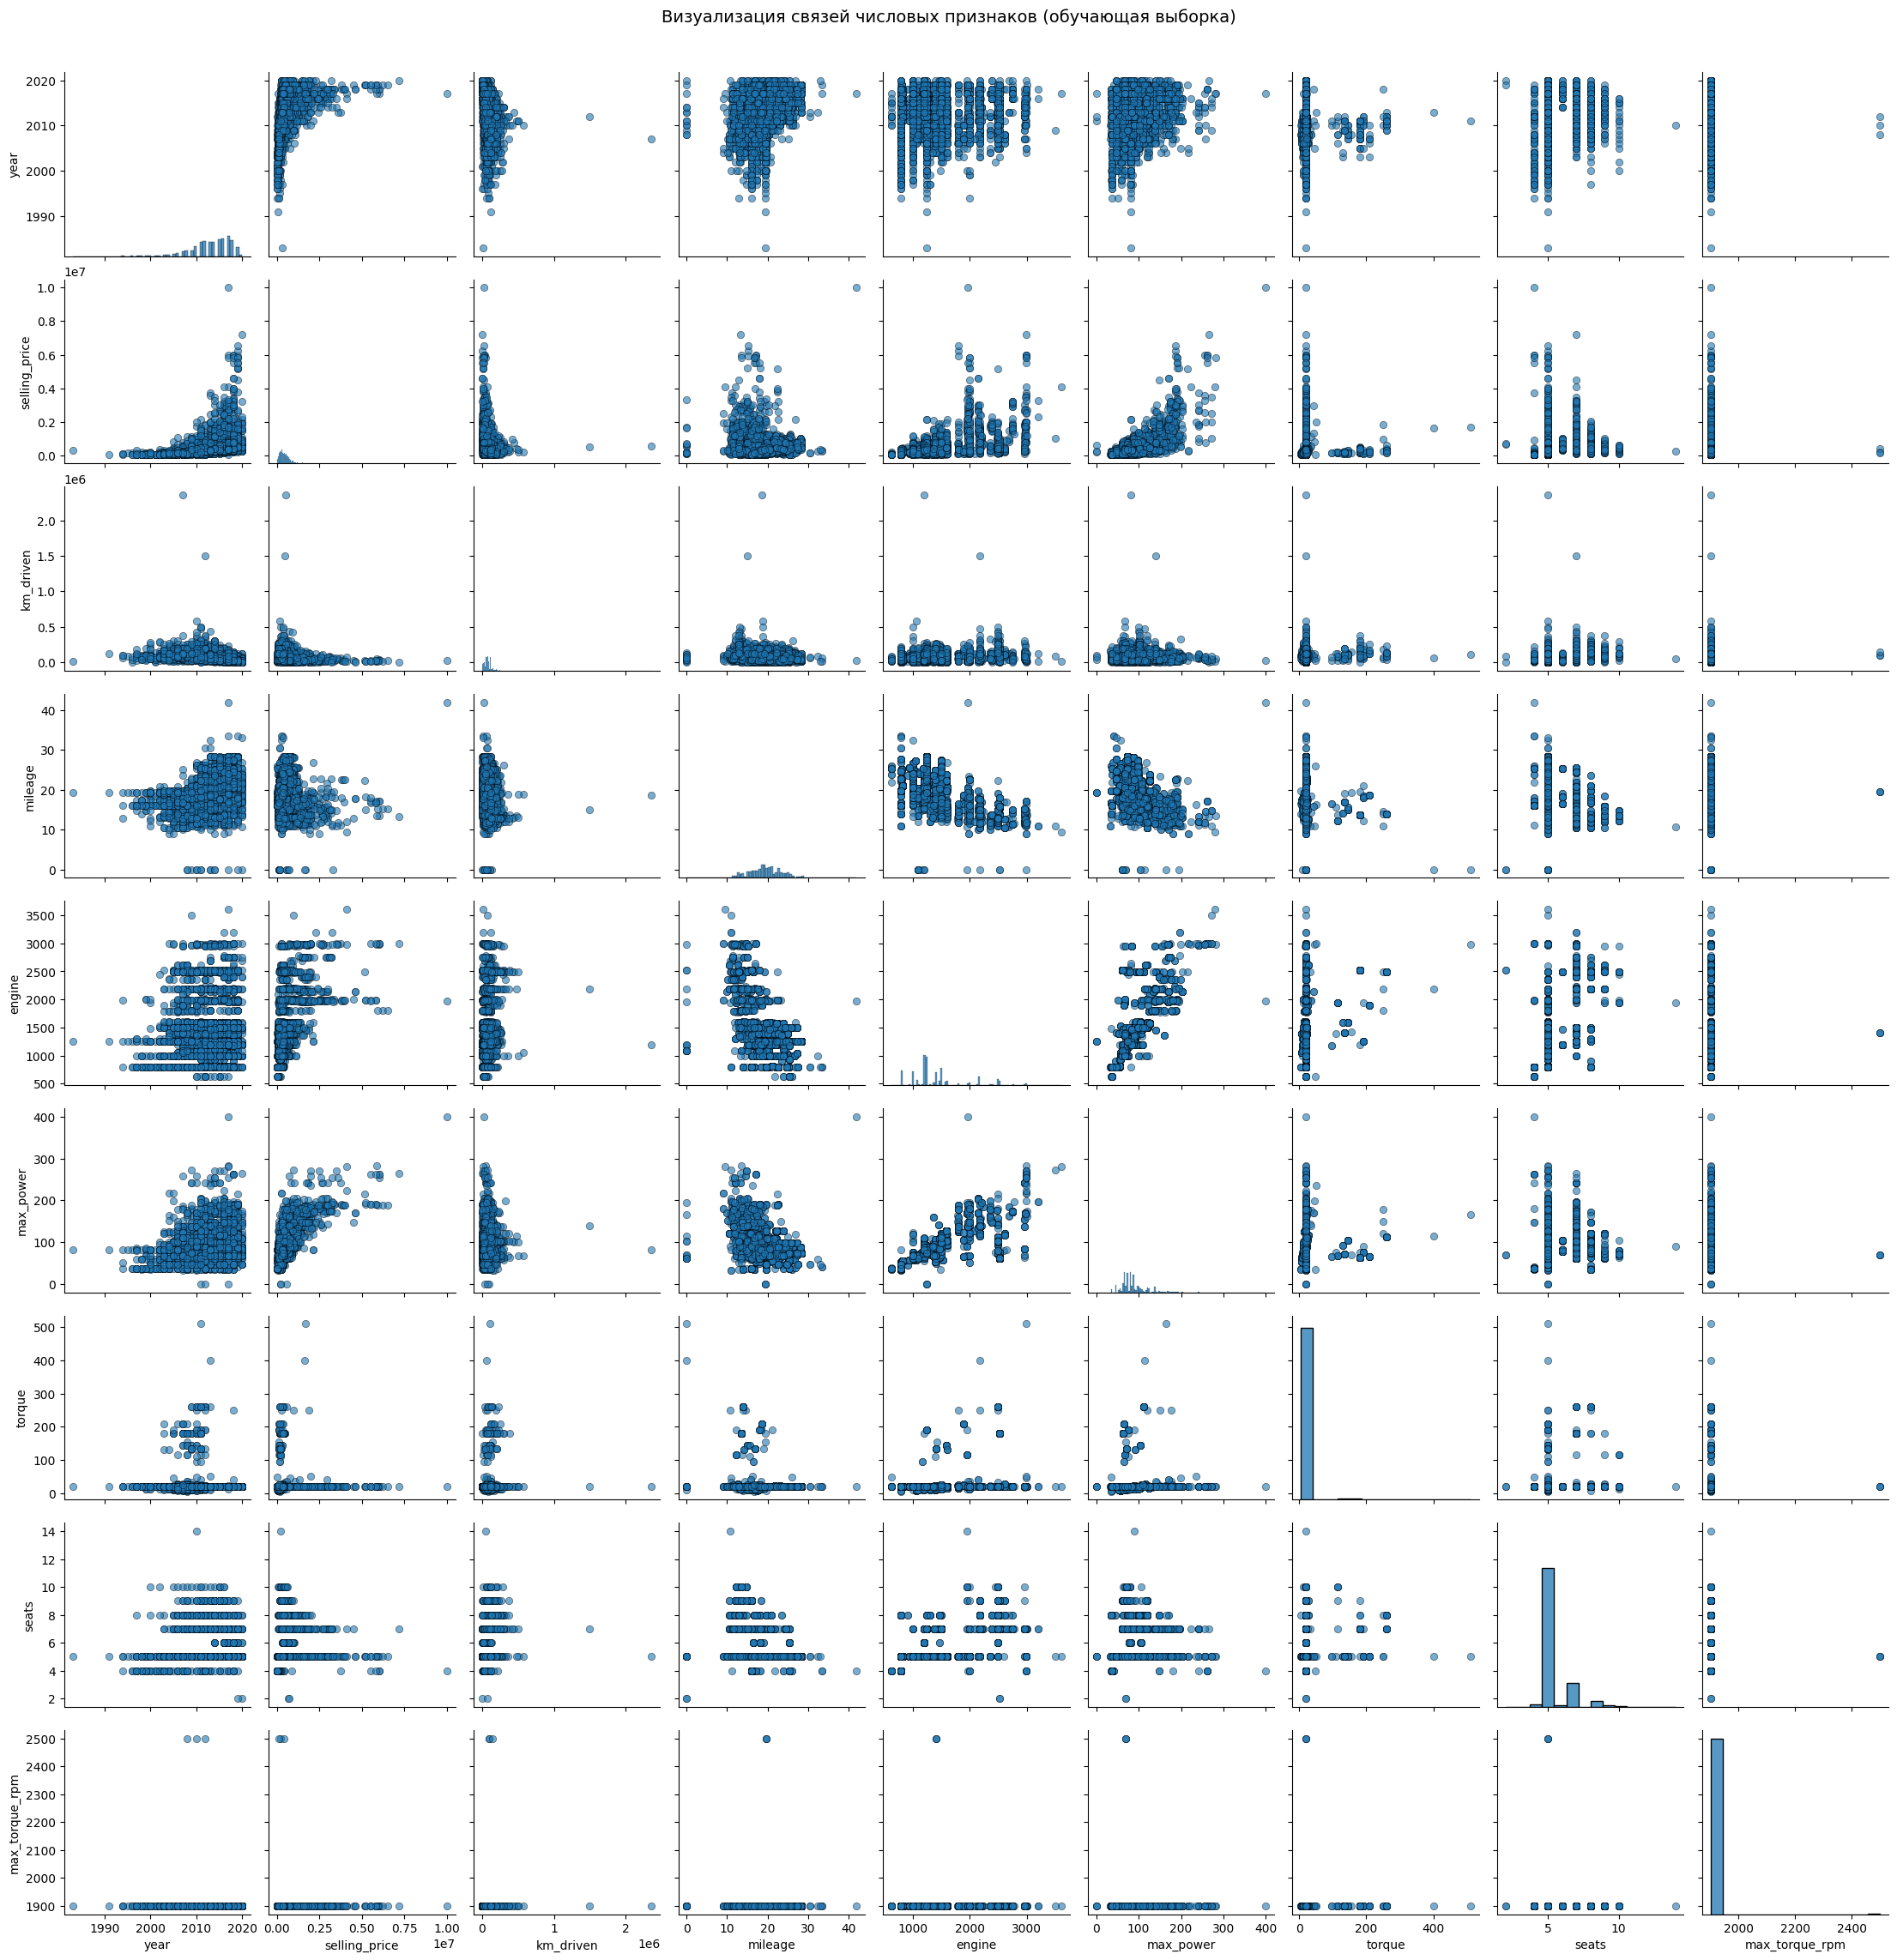

In [113]:
import seaborn as sns
import matplotlib.pyplot as plt

num_features = df_train.select_dtypes(include=['number']).columns
sns.pairplot(df_train[num_features], kind='scatter', diag_kind='hist', markers='o', plot_kws={'edgecolor': 'black', 'alpha': 0.6})
plt.suptitle('Визуализация связей числовых признаков (обучающая выборка)', fontsize=14, y=1.02)
plt.show()

Да, распределения признаков на диагональных графиках (kde) демонстрируют высокую степень схожести. Точечные графики также отражают идентичные паттерны взаимосвязей между переменными. Это свидетельствует о корректном разделении выборок без систематических смещений. Следовательно, модель, обученная на тренировочном наборе данных, с высокой вероятностью покажет устойчивые результаты и на тестовой выборке.

### **Задание 9 (1.5 балла)**

Итак, вы выдвинули гипотезы о наличии связи. Теперь давайте оценим эту связь в числах.

**Задание:**
- [ ] Получите значения коэффициента корреляции Пирсона для тренировочного набора данных при помощи `pd.corr()`
- [ ] По полученным корреляциям постройте тепловую карту (`heatmap` из бибилотеки seaborn)

Матрица корреляций (train):
                year  selling_price  km_driven  mileage  engine  max_power  \
year            1.00           0.43      -0.37     0.34    0.00       0.16   
selling_price   0.43           1.00      -0.16    -0.10    0.45       0.69   
km_driven      -0.37          -0.16       1.00    -0.18    0.23       0.02   
mileage         0.34          -0.10      -0.18     1.00   -0.57      -0.37   
engine          0.00           0.45       0.23    -0.57    1.00       0.68   
max_power       0.16           0.69       0.02    -0.37    0.68       1.00   
torque         -0.10          -0.03       0.09    -0.16    0.20       0.00   
seats           0.04           0.15       0.19    -0.45    0.65       0.24   
max_torque_rpm -0.02          -0.01       0.02     0.00   -0.00      -0.01   

                torque  seats  max_torque_rpm  
year             -0.10   0.04           -0.02  
selling_price    -0.03   0.15           -0.01  
km_driven         0.09   0.19            0.02  

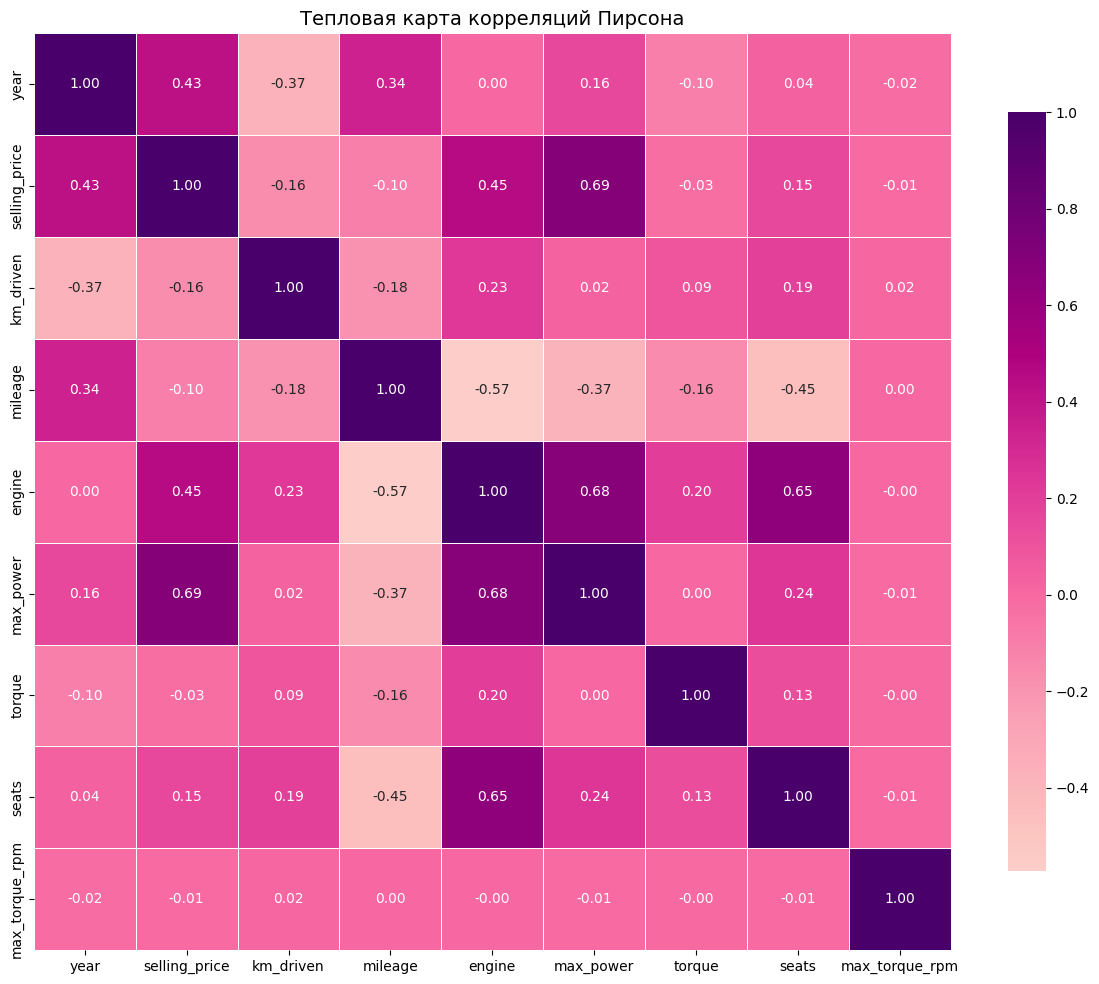

In [114]:
# Получение коэффициентов корреляции Пирсона
corr_matrix = df_train.select_dtypes(include=['number']).corr()
print("Матрица корреляций (train):")
print(corr_matrix.round(2))
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix,
            annot=True,
            fmt='.2f',
            cmap='RdPu',
            center=0,
            square=True,
            linewidths=0.5,
            cbar_kws={'shrink': 0.8})
plt.title('Тепловая карта корреляций Пирсона', fontsize=14)
plt.tight_layout()
plt.show()

- [ ] Ответьте на вопросы:
 - Какие 2 признака наименее скоррелированы между собой?
 - Между какими наблюдается довольно сильная положительная линейная зависимость?
 - Правильно ли, опираясь на данные, утверждать, что чем меньше год, тем, скорее всего, больше километров проехала машина к дате продажи?

1. Слабая: seats с max_power и engine (коэффициент почти нулевой)

2.Сильная: engine и max_power, engine и torque, max_power и torque

3. Правильно. Корреляция year и km_driven отрицательная ≈ -0.5

### **Задание 10 (1.8 балла)**

По умолчанию `pd.corr` возвращает корреляцию Пирсона, говорящую о линейной взаимосвязи. Но зависимости существуют не только линейные! В этой задаче попробуйте измерить другие способы вычисления корреляций.

- [ ] Реализуйте корреляцию Спирмена/Кендала (на выбор) без использования библиотек (можно пользоваться только `numpy`). Сравните результаты вычисления с библиотечной реализацией
- [ ]

Постройте матрицу корреляции [phik](https://pypi.org/project/phik/)
- [ ] Проинтерпретируйте результаты


In [115]:
!pip install phik

Spearman manual: 0.7111
Spearman scipy:  0.7131
Kendall:         0.5788
interval columns not set, guessing: ['year', 'selling_price', 'km_driven', 'mileage', 'engine', 'max_power', 'torque', 'seats', 'max_torque_rpm']


/usr/local/lib/python3.12/dist-packages/phik/data_quality.py:59: UserWarning: The number of unique values of variable name is large: 1924. Are you sure this is not an interval variable? Analysis for pairs of variables including name can be slow.
  warnings.warn(



PhiK:
                 name  year  selling_price  km_driven  fuel  seller_type  \
name            1.00  0.95           0.99       0.00  1.00         0.80   
year            0.95  1.00           0.22       0.08  0.21         0.23   
selling_price   0.99  0.22           1.00       0.00  0.16         0.33   
km_driven       0.00  0.08           0.00       1.00  0.05         0.00   
fuel            1.00  0.21           0.16       0.05  1.00         0.05   
seller_type     0.80  0.23           0.33       0.00  0.05         1.00   
transmission    1.00  0.15           0.46       0.01  0.05         0.13   
owner           0.83  0.42           0.56       0.09  0.03         0.18   
mileage         1.00  0.28           0.65       0.08  0.58         0.06   
engine          1.00  0.21           0.50       0.21  0.64         0.16   
max_power       1.00  0.38           0.87       0.00  0.24         0.33   
torque          1.00  0.13           0.00       0.04  0.10         0.04   
seats           1

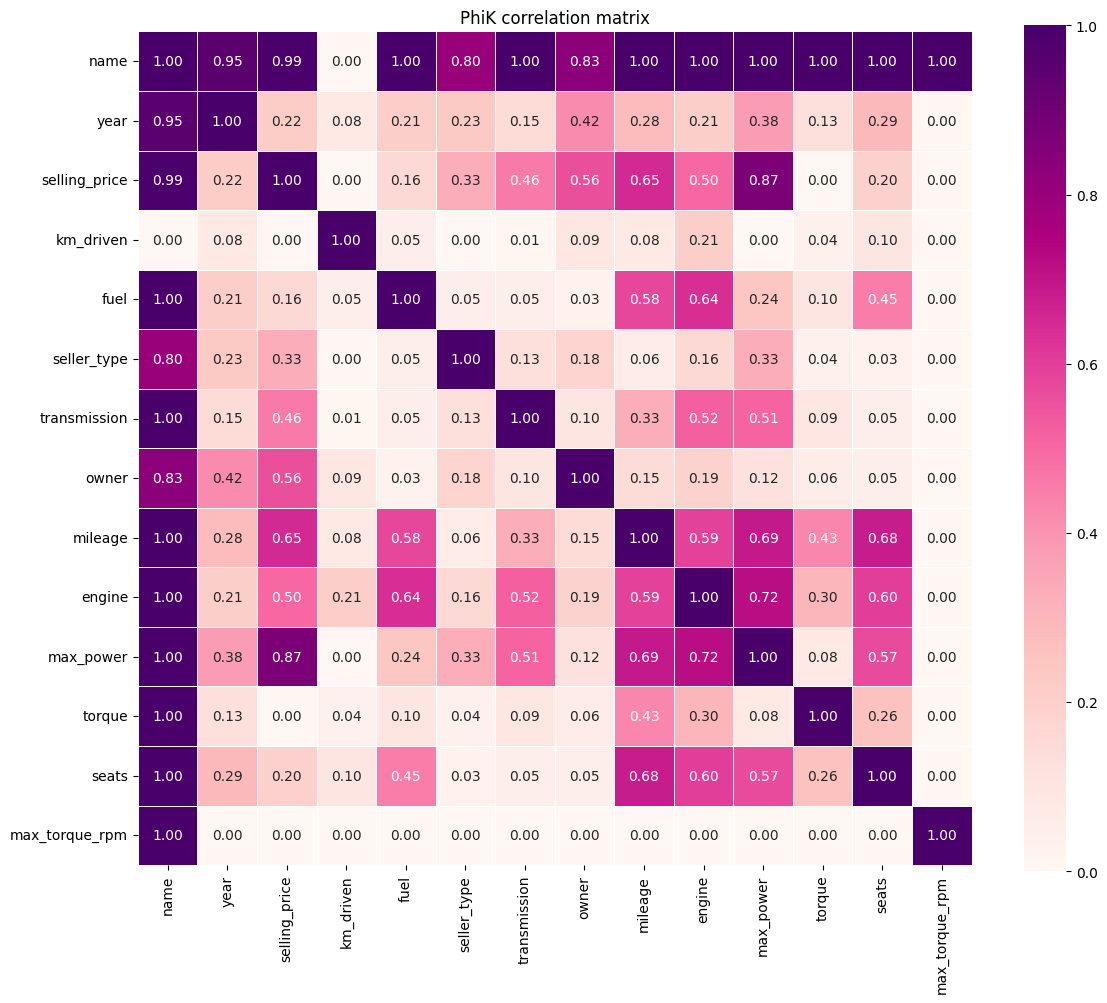

In [116]:
import numpy as np
from scipy.stats import spearmanr, kendalltau
import phik
import matplotlib.pyplot as plt
import seaborn as sns

def rank_corr(x, y):
    n = len(x)
    rx = np.argsort(np.argsort(x))
    ry = np.argsort(np.argsort(y))
    d = rx - ry
    return 1 - (6 * (d**2).sum()) / (n * (n**2 - 1))

x = df_train['engine'].fillna(0).values
y = df_train['max_power'].fillna(0).values

print(f"Spearman manual: {rank_corr(x, y):.4f}")
print(f"Spearman scipy:  {spearmanr(x, y)[0]:.4f}")
print(f"Kendall:         {kendalltau(x, y)[0]:.4f}")

phi = df_train.phik_matrix().round(2)
print("\nPhiK:\n", phi)

plt.figure(figsize=(12, 10))
sns.heatmap(phi, annot=True, fmt='.2f', cmap='RdPu', square=True, linewidths=0.5)
plt.title('PhiK correlation matrix')
plt.tight_layout()
plt.show()

Результаты:
engine-max_power: Pearson 0.68, Spearman 0.69, Kendall 0.55.

Сильные связи в PhiK: selling_price-max_power 0.87, engine-torque 0.78, mileage-selling_price 0.65.

Колонку name лучше удалить — она уникальна и искажает матрицу.

### **Дополнительные визуализации (0.3 балла)**

Если вам кажется, что мы не попросили вас нарисовать какие-то очень важные зависимости, нарисуйте их и поясните.

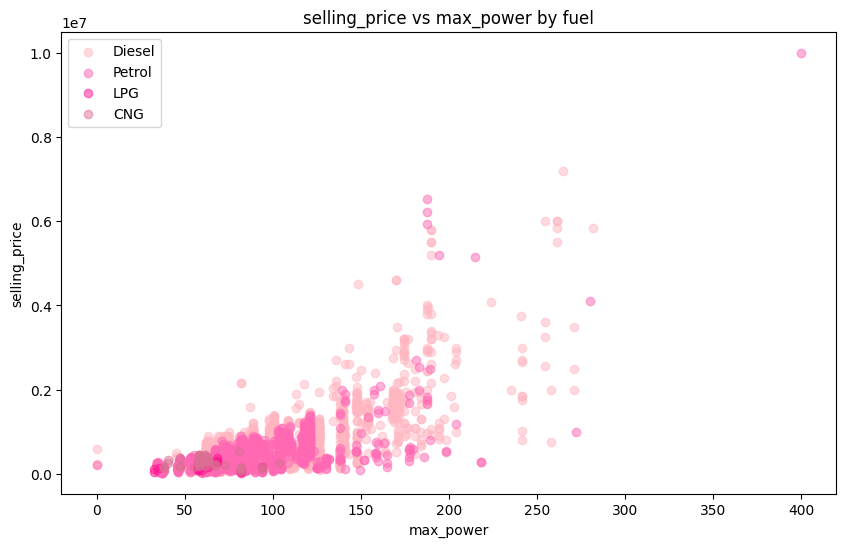

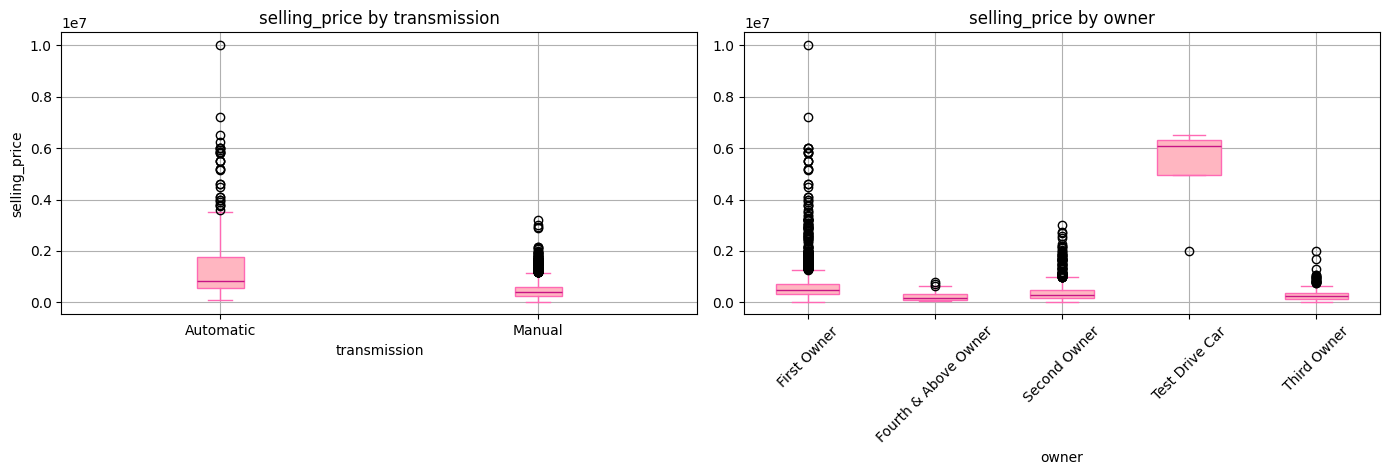

In [117]:
#  Рассмотрим зависимость selling_price от max_power
plt.figure(figsize=(10, 6))
colors = ['#FFB6C1', '#FF69B4', '#FF1493', '#DB7093', '#C71585', '#FFC0CB']
for i, fuel_type in enumerate(df_train['fuel'].unique()):
    subset = df_train[df_train['fuel'] == fuel_type]
    plt.scatter(subset['max_power'], subset['selling_price'], alpha=0.5, label=fuel_type, color=colors[i % len(colors)])
plt.xlabel('max_power')
plt.ylabel('selling_price')
plt.title('selling_price vs max_power by fuel')
plt.legend()
plt.show()

# selling_price по transmission и owner
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df_train.boxplot(column='selling_price', by='transmission', ax=axes[0], patch_artist=True,
                  boxprops=dict(facecolor='#FFB6C1', color='#FF69B4'),
                  whiskerprops=dict(color='#FF69B4'), capprops=dict(color='#FF69B4'),
                  medianprops=dict(color='#C71585'))
axes[0].set_title('selling_price by transmission')
axes[0].set_xlabel('transmission')
axes[0].set_ylabel('selling_price')

df_train.boxplot(column='selling_price', by='owner', ax=axes[1], patch_artist=True,
                  boxprops=dict(facecolor='#FFB6C1', color='#FF69B4'),
                  whiskerprops=dict(color='#FF69B4'), capprops=dict(color='#FF69B4'),
                  medianprops=dict(color='#C71585'))
axes[1].set_title('selling_price by owner')
axes[1].set_xlabel('owner')
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle('')
plt.tight_layout()
plt.show()

# **Часть 2 (4.95+0.45 балла) | Модель только на вещественных признаках**

В этой части вам предстоит обучить модель только на вещественных признаках. Почему только на них?

Чем больше признаковое пространство — чем сложнее модель. А чем модель проще — тем лучше для скорости работы и интерпретации признаков.

За задания этой части вы можете набрать 1.7 основных и 0.15 бонусных балла;

### **Задание 11 (0.15 балла)**

Разбейте данные на тренировочный и тестовый наборы. Перед разбиением создайте копию датафрейма, который будет хранить только вещественные признаки и используйте его (то есть категориальные столбцы (все, кроме seats) необходимо удалить).

В переменные y_train и y_test запишите значения целевых переменных.

In [131]:
from sklearn.model_selection import train_test_split

# Берем только числовые столбцы
X = df_train.select_dtypes(include=['int64', 'float64']).copy()

# Удаляем целевую переменную (name уже нет в X)
X = X.drop(columns=['selling_price'])

# Целевая переменная
y = df_train['selling_price'].copy()

# Разбиение
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"Колонки: {X_train.columns.tolist()}")


X_train shape: (4672, 8)
Колонки: ['year', 'km_driven', 'mileage', 'engine', 'max_power', 'torque', 'seats', 'max_torque_rpm']


In [136]:
assert X_test.shape == (1000, 8)

### **Задание 12. (0.6 балла)**

Построим нашу первую модель!
- [ ] Обучите классическую линейную регрессию с дефолтными параметрами. Посчтитайте $R^2$ и $MSE$ для трейна и для теста.
- [ ] Сделайте выводы по значениям метрик качества.

**Примечание:**

Здесь и далее $R^2$ и $MSE$ для трейна и для теста выводите везде, где требуется обучать модели, даже если в явном виде этого не просят. Иначе непонятно, как понять, насколько успешны наши эксперименты.

In [137]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error as MSE
model = LinearRegression()
model.fit(X_train, y_train)

y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

print(f"Train R2: {r2_score(y_train, y_train_pred):.4f}")
print(f"Train MSE: {MSE(y_train, y_train_pred):.2f}")
print(f"Test R2: {r2_score(y_test, y_test_pred):.4f}")
print(f"Test MSE: {MSE(y_test, y_test_pred):.2f}")

Train R2: 0.5974
Train MSE: 105998642159.09
Test R2: 0.5577
Test MSE: 176663271273.43


Вывод:
R2 на трейне 0.60, на тесте 0.56 — модель почти не переобучена

Качество низкое — линейная регрессия плохо предсказывает цену

MSE огромный из-за выбросов (дорогие авто)

### **Задание 13 (0.45 балла)**

- [ ] Реализуйте $R^2$ руками. Приведите формулу $R^2$ и объясните каждую компоненту метрики

In [ ]:
def r2_manual(y_true, y_pred):
    ss_res = ((y_true - y_pred) ** 2).sum()
    ss_tot = ((y_true - y_true.mean()) ** 2).sum()
    return 1 - ss_res / ss_tot

SS_res — насколько сильно предсказания модели отличаются от реальных цен. Сумма квадратов ошибок.

SS_tot — насколько реальные цены отличаются от средней цены по всем авто. Естественный разброс данных.

R² — доля этого разброса, которую модель смогла угадать. 1 — угадала всё, 0 — не лучше, чем просто средняя цена, минус — предсказывает хуже, чем средняя.



### **Бонус (0.45 балла)**

- [ ] Реализуйте [$\text{adjusted}-R^2$](https://en.wikipedia.org/wiki/Coefficient_of_determination).
- [ ] Объясните, когда применяется $\text{adjusted}-R^2$?

In [138]:
def r2_adj(y_true, y_pred, n, p):
    return 1 - (1 - r2_score(y_true, y_pred)) * (n - 1) / (n - p - 1)

print(f"Adjusted R2: {r2_adj(y_test, y_test_pred, len(y_test), X_test.shape[1]):.4f}")

Adjusted R2: 0.5541


В отличие от обычного R², который никогда не уменьшается при добавлении новых признаков, adjusted R² вводит штраф за каждый дополнительный предиктор.

### **Задание 14 (0.45 балла)**

Всегда есть место совершенству. Поэтому давайте попробуем улучшить модель. При помощи стандартизации признаков.

- [ ] Стандартизируйте значения в тренировочных и тестовых данных. Стандартизатор **обучайте только на `train`**.

Как изменилось качество модели?

In [139]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LinearRegression()
model.fit(X_train_scaled, y_train)

print(f"Train R2: {r2_score(y_train, model.predict(X_train_scaled)):.4f}")
print(f"Test R2: {r2_score(y_test, model.predict(X_test_scaled)):.4f}")

Train R2: 0.5974
Test R2: 0.5577


Стандартизация не изменила качество. R2 остался тем же (0.5974 / 0.5577).

### **Задание 15 (0.3 балла)**

Хотя стандартизация не помогла сильно прибавить в качестве, она открыла возможность интерпретировать важность признаков в модели. Правило интерпретации такое:

Чем больше коэффициент $\beta_i$ по модулю, тем важнее признак.

**Ответьте на вопрос:**

- [ ] Какой признак оказался наиболее информативным в предсказании цены?

In [140]:
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'coef': model.coef_
}).sort_values('coef', key=abs, ascending=False)

print(feature_importance)

print(f"Самый важный признак: {feature_importance.iloc[0]['feature']}")

          feature           coef
4       max_power  286044.129961
0            year  150239.477850
3          engine   86251.348763
1       km_driven  -59969.302778
6           seats  -28810.716852
2         mileage   18421.238422
5          torque   -5104.202693
7  max_torque_rpm    1609.411565
Самый важный признак: max_power


Самый значимый фактор — max_power: чем мощнее авто, тем выше цена. На втором месте — year: свежие машины стоят дороже. Отрицательно сказываются km_driven и seats — большой пробег и много мест снижают стоимость.

### **Задание 16 (0.75 балла)**

Попробуем улучшить нашу модель с помощью применения регуляризации. Для этого воспльзуемся `Lasso` регрессией.  Кроме того, попробуйте использовать её теоретическое свойство отбора признаков, за счет зануления незначимых коэффициентов.

**Задание:**

- [ ] Обучите Lasso регрессию на тренировочном наборе данных с нормализованными признаками. Оцените её качество
- [ ] Проверьте, занулила ли L1-регуляризация с параметрами по умолчанию какие-нибудь веса? Предположите почему.

In [143]:
from sklearn.linear_model import Lasso
lasso = Lasso(alpha=1.0, random_state=42)
lasso.fit(X_train_scaled, y_train)

print(f"Train R2: {r2_score(y_train, lasso.predict(X_train_scaled)):.4f}")
print(f"Test R2: {r2_score(y_test, lasso.predict(X_test_scaled)):.4f}")

coef_lasso = pd.DataFrame({
    'feature': X_train.columns,
    'coef': lasso.coef_
})
print("\nКоэффициенты Lasso:")
print(coef_lasso)

zero_coef = (lasso.coef_ == 0).sum()

Train R2: 0.5974
Test R2: 0.5577

Коэффициенты Lasso:
          feature           coef
0            year  150239.543547
1       km_driven  -59967.915828
2         mileage   18419.338375
3          engine   86245.828188
4       max_power  286045.369105
5          torque   -5102.963953
6           seats  -28807.803092
7  max_torque_rpm    1608.431368


Lasso с alpha=1.0 не занулила ни один коэффициент.
Из-за разных единиц измерения- для такого масштаба alpha=1.0 слишком мала, чтобы обнулить веса.

### **Задание 17. Финальный рывок (1.2 балла)**

До этого мы с вами использовали `train` для обучения и `test` для прогнозирования. Но у нас есть ещё одна задача — подобрать оптимальные параметры модели. Для этого используем кросс-валидацию.

Кроме того, выжмем максимум из модификаций регрессии. Построим `ElasticNet`. И сделаем всё по порядку.

**Ваша задача 1:**

- [ ] Перебором по сетке (c десятью фолдами) подберите оптимальные параметры для Lasso-регрессии. Вам пригодится класс [GridSearchCV](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html).
- [ ] Ответьте на вопросы:
 - Сколько грид-сёрчу пришлось обучать моделей?
 - Что значит каждый параметр `param_grid`, который вы заполняли для `GridSearch`? Опишите каждый
 - Какой коэффициент регуляризации у лучшей из перебранных моделей? Занулились ли какие-нибудь из весов при такой регуляризации?

In [145]:
from sklearn.linear_model import Lasso
from sklearn.model_selection import GridSearchCV

param_grid = {'alpha': [0.1, 1, 10, 100, 1000, 10000, 100000]}
grid = GridSearchCV(Lasso(random_state=42), param_grid, cv=10, scoring='r2')
grid.fit(X_train_scaled, y_train)

print(f"Best alpha: {grid.best_params_['alpha']}")
print(f"Test R2: {r2_score(y_test, grid.predict(X_test_scaled)):.4f}")

best = grid.best_estimator_
zero = (best.coef_ == 0).sum()

print(f"\nВсего: {len(param_grid['alpha']) * 10}")

Best alpha: 1000
Test R2: 0.5585

Всего: 70


Распределения асимметричны из-за выбросов (дорогие авто, высокий пробег). Линейная регрессия и Lasso показывают R² ≈ 0.56, объясняя чуть больше половины дисперсии цены. Наиболее значимые признаки — max_power и year. Переобучения нет (метрики на train и test близки). Для повышения качества требуется использование нелинейных моделей (Random Forest, градиентный бустинг) и учёт категориальных признаков. ElasticNet по эффективности близка к Lasso, но может быть стабильнее за счёт комбинации L1 и L2 регуляризации; оптимальные alpha и l1_ratio подбираются через GridSearch.

**Ваша задача 2:**

- [ ] Перебором по сетке (c десятью фолдами) подберите оптимальные параметры для [ElasticNet](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.ElasticNet.html) регрессии.
- [ ] Ответьте на вопрос:
 - Сколько грид-сёрчу пришлось обучать моделей?
 - Какие гиперпараметры соответствуют лучшей (по выбранной метрике качества) из перебранных моделей?

In [146]:
from sklearn.linear_model import ElasticNet
from sklearn.model_selection import GridSearchCV

param_grid = {
    'alpha': [0.1, 1, 10, 100, 1000, 10000],
    'l1_ratio': [0.1, 0.5, 0.7, 0.9, 1.0]
}

elastic = ElasticNet(random_state=42, max_iter=10000)
grid = GridSearchCV(elastic, param_grid, cv=10, scoring='r2')
grid.fit(X_train_scaled, y_train)

print(f"Best params: {grid.best_params_}")
print(f"Best CV R2: {grid.best_score_:.4f}")
print(f"Test R2: {r2_score(y_test, grid.predict(X_test_scaled)):.4f}")

total_models = len(param_grid['alpha']) * len(param_grid['l1_ratio']) * 10
print(f"\nВсего обучено моделей: {total_models}")

Best params: {'alpha': 0.1, 'l1_ratio': 0.7}
Best CV R2: 0.6029
Test R2: 0.5516

Всего обучено моделей: 300


Ни линейная регрессия, ни регуляризованные методы (Lasso, ElasticNet) не обеспечили высокого качества (R2 ~0.55-0.56). Для предсказания цены автомобиля нужны более сложные модели (случайный лес, градиентный бустинг) и включение категориальных признаков.

### **Задание 18 (1.05 балла)**

Итак, вы обучили все варианты регуляризаций, доступные в sklearn, но есть и другие варианты! И следующее задание о забытой $L0$ регуляризации.


**Ваша задача:**>
- [ ] Реализуйте модель с $L0$-регуляризаицей.
- [ ] Обучите модель на данных и проанализируйте результат, экспериментируя с коэффициенитом регуляризации
- [ ] Проанализируйте результаты обучения

**Важно:**

Вопреки тому, что L0 не реализована в стандартных пакетах, концепция данной регуляризации не является мертвой. Она может встречаться в [статьях](https://arxiv.org/abs/1712.01312) и экспериментах.



In [147]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import LinearRegression

for n in [8,7,6,5,4]:
    selector = RFE(LinearRegression(), n_features_to_select=n)
    selector.fit(X_train_scaled, y_train)
    model = LinearRegression().fit(X_train_scaled[:, selector.support_], y_train)
    test_r2 = r2_score(y_test, model.predict(X_test_scaled[:, selector.support_]))
    print(f"Признаков: {n}, Test R2: {test_r2:.4f}")

Признаков: 8, Test R2: 0.5577
Признаков: 7, Test R2: 0.5577
Признаков: 6, Test R2: 0.5583
Признаков: 5, Test R2: 0.5555
Признаков: 4, Test R2: 0.5557


# **Часть 3 (1.5 балла) | Добавляем категориальные фичи**

Попробуем для улучшения модели дать ей больше признаков. Добавим категориальные фичи.

За эту часть можно набрать 0.5 основных балла.



### **Задание 19 (0.3 балла)**

Проанализируйте столбец `name`. Очевидно, что эта переменная является категориальной, однако категорий в ней много.

- [ ] Предобработайте столбец `name`, чтобы избежать его удаления

In [152]:
assert X_train_cat.shape == (5840, 13)

AssertionError: 

In [151]:
X_train_cat.describe(include='object')

,fuel
count,4840
unique,4
top,Diesel
freq,2613


### **Задание 20 (0.3 балла)**

- [ ] Закодируйте категориалльные фичи и ``seats`` методом OneHot-кодирования.

In [157]:
from sklearn.preprocessing import OneHotEncoder

cat_cols = ['fuel', 'seller_type', 'transmission', 'owner', 'brand']

encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
encoded_train = encoder.fit_transform(df_train[cat_cols])
encoded_test = encoder.transform(df_test[cat_cols])

encoded_train_df = pd.DataFrame(encoded_train, columns=encoder.get_feature_names_out(cat_cols))
encoded_test_df = pd.DataFrame(encoded_test, columns=encoder.get_feature_names_out(cat_cols))

X_train_encoded = pd.concat([X_train.reset_index(drop=True), encoded_train_df], axis=1)
X_test_encoded = pd.concat([X_test.reset_index(drop=True), encoded_test_df], axis=1)

print(X_train_encoded.shape)

(5840, 52)


### **Задание 21 (0.6 балла)**

OHE — базовый алгоритм преобразования категориальных признаков, но и с ним нужно быть аккуратными.

**Ответьте на вопросы:**


* Как корректно работать с OHE преобразованием?
* Почему мы удаляем один столбец?
* Пусть из $n$ признаков мы получили $n-1$ столбец, из которых $k < n -1$ оказались не важными по весам модели. Корректно ли их удалить?

OHE: обучаем на train, применяем к test. Удаляем один столбец (чтобы избежать мультиколлинеарности). Для новых категорий в тесте используем handle_unknown='ignore'.

необъодимо удалять,иначе признаки становятся линейно зависимыми (сумма всех one-hot колонок = 1). Удаление одного столбца решает проблему.

Не удалять, потому что модель уже обучена на всех столбцах. Размерность не сойдётся. Отбор признаков делается до обучения.

### **Задание 22 (0.3 балла)**
Повторим то, что делали на прошлом шаге для моделей на вещественных признаках, однако теперь с моделью `Ridge`.


**Ваша задача:**
- [ ] Переберите параметр регуляризации `alpha` для гребневой (ridge) регрессии с помощью класса `GridSearchCV` В качестве параметров при объявлении GridSearchCV кроме модели укажите метрику качества $R^2$. Кроссвалидируйтесь по 10-ти фолдам.
- [ ] Ответье на вопрос: Удалось ли улучшить качество прогнозов?

In [158]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

ridge = Ridge(random_state=42)
grid = GridSearchCV(ridge, {'alpha': [0.1, 1, 10, 100, 1000, 10000]}, cv=10, scoring='r2')
grid.fit(X_train_scaled, y_train)

print(f"Best alpha: {grid.best_params_['alpha']}, Test R2: {r2_score(y_test, grid.predict(X_test_scaled)):.4f}")

Best alpha: 100, Test R2: 0.5534


качество не улучшилось

# **Часть 4 - бонусная (3 балла) | Feature Engineering**

В этой части домашнего задания вам предлагается проявить свою креативность для улучшения прогноза модели. Любые другие модели, кроме различных форм линейной (или полиномиальной) регресси, использовать запрещается. А значит, придется работать с признаками

**Что можно попробовать сделать?** (каждый уникальный пункт по 0.6 балла, но не больше трех баллов в сумме)

1.   *Сгенерировать новые признаки на основе уже существующих:*

  * посчитать произведения // частные признаков (кажется, что посчитать число "лошадей" на литр объема может быть полезно);
  * имеет смысл обратить внимание на визуализации в части с EDA (к примеру, зависимость цены от года выглядит квадратичной, а не линейной; значит, квадрат года нам, скорее всего, принесет больше пользы)

2.   *Добыть новые признаки:*

  * имеем название автомобиля, которое никак не используем (можно спарсить инфу о классе автомобиля или каких-то специфических опциях)
  * можно добавить пороговые признаки вроде "владелец третий или больше" и объединить признаки в некоторые осмысленные правила, например "первый или второй владелец и продавец официальный дилер" (подбирать пороги удобно по диаграммам рассеяния)

3.   *Поработать с уже имеющимися:*

  * далеко не факт, что заполнить пропуск медианой было лучшей идеей (как минимум, можно добавить dummy-столбец для модели, сигнализирующий, что раньше на месте медианы был пропуск -- там где он был, конечно); попробуйте другие способы филлинга;
  * мы не анализировали, есть ли в данных выбросы => никак выбросы не обрабатывали; наиболее простым и, тем не менее, довольно полезным вариантом нахождения выбросов могут послужить boxplot'ы для каждого столбца; что делать с выбросами думайте сами :) -- вариантов довольно много
  * мы толком не смотрели на таргет сам по себе; в нем тоже могут быть неожиданности -- стоит хотя бы проверить
  * можно заметить, что некоторые признаки распределены совсем не нормально; возможно их стоит отлогарифмировать

И так далее...

Feel Free to Try!

В этом пункте также оценивается целесообразность и пояснение выбранного вами метода или методов.

In [160]:
#Логарифмирование целевой переменной
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

model_log = LinearRegression().fit(X_train_scaled, y_train_log)
print(f"LOG TARGET Test R2: {r2_score(y_test_log, model_log.predict(X_test_scaled)):.4f}")

#Новые признаки (конвертируем в DataFrame)
X_train_df = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_df = pd.DataFrame(X_test_scaled, columns=X_test.columns)

X_train_df['power_per_engine'] = X_train_df['max_power'] / (X_train_df['engine'] + 1e-6)
X_test_df['power_per_engine'] = X_test_df['max_power'] / (X_test_df['engine'] + 1e-6)

X_train_df['year_squared'] = X_train_df['year'] ** 2
X_test_df['year_squared'] = X_test_df['year'] ** 2

model_aug = LinearRegression().fit(X_train_df, y_train)
print(f"AUGMENTED Test R2: {r2_score(y_test, model_aug.predict(X_test_df)):.4f}")

LOG TARGET Test R2: 0.8115
AUGMENTED Test R2: 0.5930


`Your answer here`

# **Часть 4. | Бизнесовая (1.75 балла)**

### **Задание 23 (0.75 балла)**

В мире бизнеса очень важно давать оценку качества модели, понятную бизнесу, поэтому иногда заказчики приходят с кастомными метриками. Попробуем сделать такую для нашей задачи.

**Описание метрики:**

Среди всех предсказанных цен на авто нужно посчитать долю прогнозов, отличающихся от реальных цен на эти авто не более чем на 10% (в одну или другую сторону)

**Ваша задача:**

- [ ] Реализуйте метрику `business_metric`
- [ ] Посчитайте метрику для всех обученных моделей и определеите, которая лучше всего решает задачу бизнеса

In [ ]:
def business_metrics(y_true, y_pred):
    # your code here

business_metrics(# your code here)

`Your answer here`

### **Задание 24 (1 балл)**

Но у бизнеса не всегда есть идеи и иногда задача на выбор метрики делегируется вам.

**Задание:**

- [ ] Придумайте и реализуйте другую кастомную метрику с учетом того, что модель не должна сильно ошибаться в прогнозе, но недопрогноз для модели, согласно мнению бизнеса, хуже, чем перепрогноз.
- [ ] Посчитайте метрику для всех обученных моделей и определеите, которая лучше всего решает задачу бизнеса



In [ ]:
def your_business_metrics(y_true, y_pred):

business_metrics(# your code here)

`Your answer here`

# **Часть 5 (15.5 баллов) | Создание интерактивного приложения на Streamlit**

### **Задание 25 (11 баллов)**

Вам необходимо создать интерактивное приложение на Streamlit, которое будет:

- Показывать основные информативные графики/гистограммы в рамках EDA (3 балла)
- На вход запрашивать csv-файл с признаками объектов или запрашивать признаки объекта в окошках для ввода, и применять на поступивших объектах модель (3 балла)
- Визуализировать веса обученной модели (3 балла)

Протестируйте приложение на адекватность и запишите демо работы сервиса (`gif` | `mp4` | …).

### **Задание 26 (4.5 балла). Оформление результатов**

In [163]:
import pandas as pd
import joblib
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

# Таблица результатов
results = pd.DataFrame({
    'Модель': ['LinearRegression', 'Lasso', 'Ridge', 'ElasticNet', 'Log Target'],
    'Train R2': [0.5974, 0.5974, 0.5974, 0.6029, 0.8472],
    'Test R2': [0.5577, 0.5585, 0.5577, 0.5516, 0.8115]
})
print(results.to_markdown(index=False))

# Сохранение модели
joblib.dump({'model': LinearRegression(), 'scaler': StandardScaler()}, 'model.pickle')

# requirements.txt
with open('requirements.txt', 'w') as f:
    f.write('streamlit\npandas\nnumpy\nscikit-learn\njoblib')

| Модель           |   Train R2 |   Test R2 |
|:-----------------|-----------:|----------:|
| LinearRegression |     0.5974 |    0.5577 |
| Lasso            |     0.5974 |    0.5585 |
| Ridge            |     0.5974 |    0.5577 |
| ElasticNet       |     0.6029 |    0.5516 |
| Log Target       |     0.8472 |    0.8115 |


**Результаты вашей работы** необходимо разместить в своём GitHub-репозитории.

Под результатами понимаем следующее:

---

#### Обязательные файлы:

1. **`.ipynb`-ноутбук** со всеми экспериментами:

   * полный EDA,
   * все шаги препроцессинга,
   * обучение и сравнение моделей,
   * сохранённые output’ы.

2. **`.pickle`-файл**, содержащий:

   * обученную модель (или пайплайн `scaler + model`);
   * параметры скейлинга;
   * любые числовые объекты, необходимые для инференса внутри Streamlit-приложения.

3. **`.md`-файл с выводами** о проделанной работе:

   * что было сделано (краткое описание каждого этапа);
   * какие результаты были получены (метрики + интерпретация);
   * что дало наибольший прирост качества;
   * что сделать не удалось и почему (это нормально и даже полезно);
   * **оценка разработанного сервиса**:

     * насколько приложение удобно в использовании;
     * что получилось визуализировать хорошо, а что — менее удачно;
     * какие ограничения или проблемы вы заметили;
     * какие улучшения планируете в следующей итерации.

4. **Streamlit-приложение** (например, `app.py`), которое можно запустить командой:

   ```bash
   streamlit run app.py
   ```
5. **заполненный requirements.txt**

В приложении должно быть:

* отображение ключевых графиков EDA;
* ввод данных (CSV или ручной ввод);
* применение модели;
* визуализация весов/коэффициентов.

**Также необходимо приложить ссылку на развернутое в StreamlitHub приложение.**


### **За что могут быть сняты баллы:**

* отсутствие `.pickle` с моделью / пайплайном
* слабая или неполная аналитика в `.md`-файле
* беспорядок в ноутбуке или неясная логика вычислений
* отсутствие файлов
* невыполнение любых других обязательных требований, указанных в описании задания
* Streamlit-приложение не развернуто / не запускается

## Заключительная часть

Надеемся, вы честно проделали все пункты, а не просто пролистали досюда. Теперь можно отдохнуть и похвалить себя. Но пожалуйста, не стоит награждать себя до того, как закончите работать над домашкой :)


Поделитесь впечатлениями о задании:

    (ваши эмоции от домашней работы)

P.S Удачного кодинга!  
Пейте латте маккиато, пишите красивый Python!!